In [2]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib
import math


In [3]:
n_samples = 10000
n_classes = 5

x_samples = np.random.uniform(-1, 1, n_samples)

z_samples = np.random.uniform(-1, 1, n_samples)

def logistic(k):
    return 1 / (1 + np.exp(-k))

thetas = [np.zeros_like(x_samples) for _ in range(n_classes)]



slope = n_classes - 1
shift = [n_classes - 2 -2*i for i in range(n_classes-1)]

x_bins = np.linspace(-1, 1, n_classes)

y_samples = np.zeros_like(x_samples)
y_max_prob = np.zeros_like(x_samples)

labels = [i for i in range(n_classes)]

for i in range(n_samples):
    
    #find the bin for x_samples[i]
    bin_index = np.digitize(x_samples[i], x_bins) - 1
    if bin_index == n_classes - 1: #correct in case x = 1
        bin_index = n_classes - 2
    
    thetas[bin_index][i] =     logistic( -1*((slope*x_samples[i] + shift[bin_index]) + z_samples[i]))
    thetas[bin_index + 1][i] = logistic(     (slope*x_samples[i] + shift[bin_index]) + z_samples[i] )
    
    y_samples[i] = np.random.choice(labels, p=[thetas[k][i] for k in range(n_classes)])
    y_max_prob[i] = np.argmax([thetas[k][i] for k in range(n_classes)])




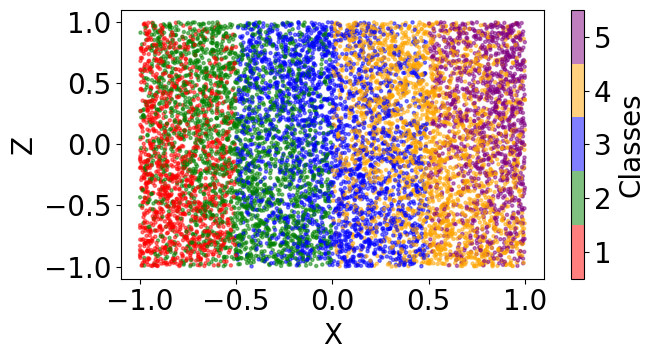

In [8]:
plt.figure(figsize=(7, 4))
#font size
plt.rcParams.update({'font.size': 20})

colorlist = ['None', 'red', 'green', 'blue', 'orange', 'purple', 'pink', 'brown', 'gray', 'cyan', 'magenta']
#discrete color map
cmap = matplotlib.colors.ListedColormap(colorlist[1:n_classes+1])
plt.scatter(x_samples, z_samples, c=y_samples+1, s=5, cmap=cmap,alpha=0.5)
plt.colorbar(ticks=range(n_classes+1), label='Classes')
plt.clim(0.5, n_classes + 0.5)
plt.xlabel('X')
plt.ylabel('Z')
plt.yticks([-1.0, -0.5, 0, 0.5, 1.0])
plt.tight_layout()
plt.savefig( '5_class_synth_samples.pdf')


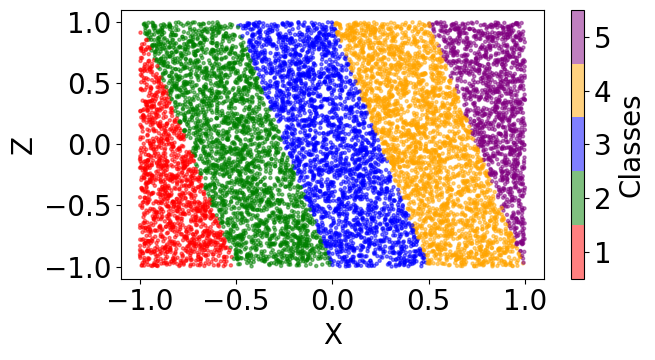

In [10]:
plt.figure(figsize=(7, 4))
#font size
plt.rcParams.update({'font.size': 20})

colorlist = ['None', 'red', 'green', 'blue', 'orange', 'purple', 'pink', 'brown', 'gray', 'cyan', 'magenta']
#discrete color map
cmap = matplotlib.colors.ListedColormap(colorlist[1:n_classes+1])
plt.scatter(x_samples, z_samples, c=y_max_prob+1, s=5, cmap=cmap,alpha=0.5)
plt.colorbar(ticks=range(n_classes+1), label='Classes')
plt.clim(0.5, n_classes + 0.5)
plt.xlabel('X')
plt.ylabel('Z')
plt.yticks([-1.0, -0.5, 0, 0.5, 1.0])
plt.tight_layout()
plt.savefig( '5_class_synth_max_prob.pdf')


In [ ]:
w1_samples = np.random.uniform(-1.1, 1.5, n_samples)
w2_samples = np.random.uniform(-1.1, 1.5, n_samples)

w1_bins = np.linspace(-1.1, 1.5, n_classes+1)

y_samples = np.zeros_like(w1_samples)



for i in range(n_samples):
    bin_index = np.digitize(w1_samples[i], w1_bins) - 1
    y_samples[i] = bin_index

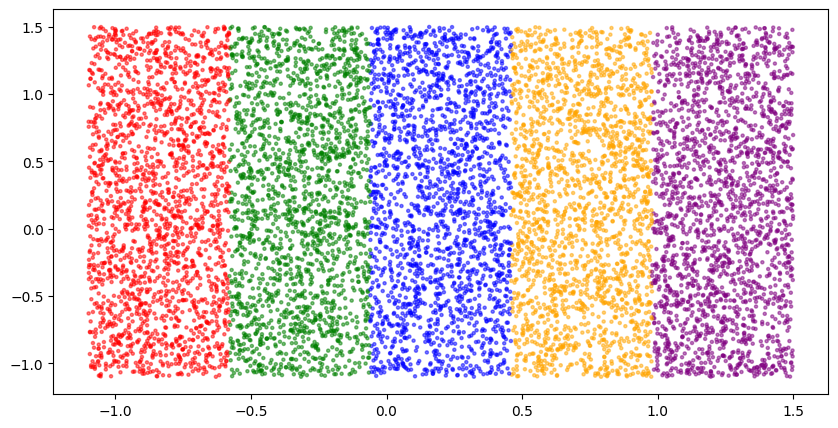

In [ ]:
plt.figure(figsize=(10, 5))
plt.scatter(w1_samples, w2_samples, c=y_samples, s=5, cmap=cmap, alpha=0.5)

In [ ]:
-math.tan(0.5/4)*180/math.pi

-7.199508999894951

(-1.0, 1.0)

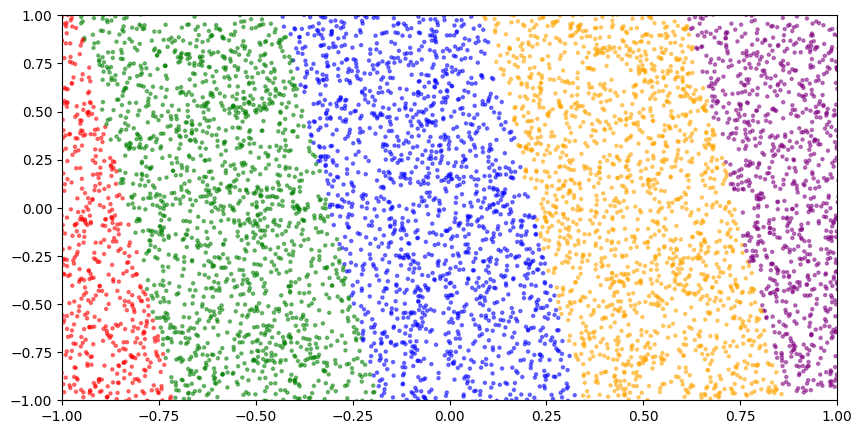

In [ ]:
theta = -math.tan(0.5/4)

x_prime = w1_samples * np.cos(theta) + w2_samples * np.sin(theta) -0.25
y_prime = -w1_samples * np.sin(theta) + w2_samples * np.cos(theta)

plt.figure(figsize=(10, 5))
plt.scatter(x_prime, y_prime, c=y_samples, s=5, cmap=cmap, alpha=0.5)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
